
# Parameter Sweep for Distance-Scaled Sudoku Rewards

Goal: choose per-episode reward scalars `(C_wrong, k_s, k_u)` for the distance-based shaping signal **without running PPO**.
This notebook now includes an optional cache-builder cell that computes distance stats from the full puzzle corpus and plots ΔF estimates per difficulty bin. The compute step is gated by a flag so you don't run it accidentally.


In [11]:

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def find_project_root(start: Path, marker="notebooks"):
    cur = start.resolve()
    for parent in (cur, *cur.parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError("Could not locate project root containing: " + marker)

PROJECT_ROOT = find_project_root(Path.cwd())

sns.set_context("talk")
sns.set_style("whitegrid")
CACHE_PATH = PROJECT_ROOT.joinpath("data", "processed", "reward_sweep_cache.json")


## Optional: compute/cache distance stats (ΔF) and plot per bin
Set `RUN_COMPUTE = True` to regenerate stats and plots. By default it only loads existing cache.

What it does when enabled:
- Samples puzzles from every bin (prev_mix_ratio=0) with a configurable count.
- Computes `F_start` using the distance regressor + calibrator.
- Estimates per-move drop `mu_delta_est = F_start / empties` per puzzle.
- Saves summaries to `data/processed/reward_sweep_cache.json`.
- Plots per-bin distributions of `mu_delta_est` (boxen) and `F_start` (boxen).


Wrote cache to /Users/santi/Documents/dev/sandbox/sudoku_rl/data/processed/reward_sweep_cache.json


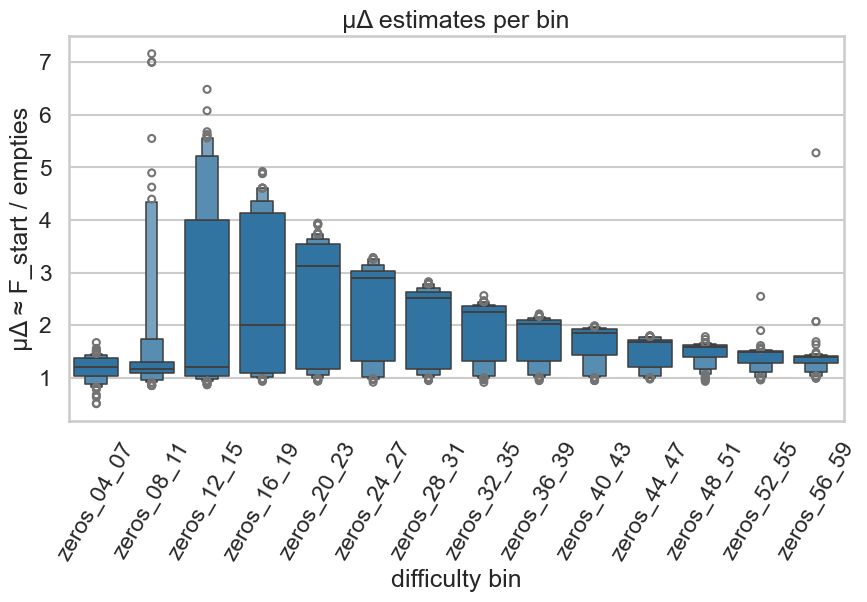

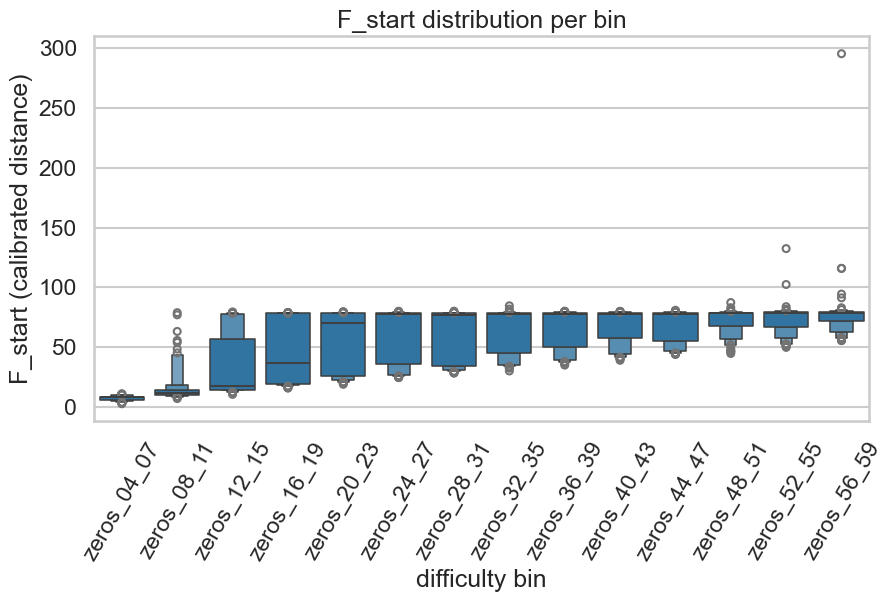

In [12]:

RUN_COMPUTE = True   # <- flip to True to recompute/cache and plot
N_PER_BIN = 100       # samples per bin when computing

if RUN_COMPUTE:
    import torch
    from sudoku_rl.puzzle import supported_bins, sample_puzzle
    from sudoku_rl.distance_regressor import DistanceRegressor, IsotonicCalibrator

    MODEL_PATH = PROJECT_ROOT / "experiments" / "distance_regressor.pt"
    CALIB_PATH = PROJECT_ROOT / "experiments" / "distance_calibrator.json"
    DEVICE = "cpu"

    # Load model + calibrator
    model = DistanceRegressor().to(DEVICE)
    state = torch.load(MODEL_PATH, map_location=DEVICE)
    if isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
    else:
        model.load_state_dict(state)
    model.eval()
    calib_data = json.loads(CALIB_PATH.read_text())
    calibrator = IsotonicCalibrator.from_dict(calib_data)

    def predict_F(board):
        x = torch.as_tensor(board.reshape(1, -1), dtype=torch.float32, device=DEVICE) / 9.0
        with torch.no_grad():
            pred = model(x).item()
        d = np.array([pred], dtype=np.float64)
        return float(calibrator.predict(d)[0])

    rows = []
    for label in supported_bins():
        for seed in range(N_PER_BIN):
            board, _ = sample_puzzle(bin_label=label, seed=seed, return_solution=True, prev_mix_ratio=0.0)
            empties = int((board == 0).sum())
            if empties == 0:
                continue
            F_start = predict_F(board)
            mu_delta_est = F_start / empties
            rows.append({
                "bin": label,
                "seed": seed,
                "F_start": F_start,
                "empties": empties,
                "mu_delta_est": mu_delta_est,
            })

    df_stats = pd.DataFrame(rows)
    def summary(series):
        return {
            "mean": float(series.mean()),
            "median": float(series.median()),
            "p10": float(series.quantile(0.10)),
            "p90": float(series.quantile(0.90)),
        }

    by_bin = {}
    for label, sub in df_stats.groupby("bin"):
        by_bin[label] = {
            "num_samples": int(len(sub)),
            "F_start": summary(sub["F_start"]),
            "empties": summary(sub["empties"]),
            "mu_delta_est": summary(sub["mu_delta_est"]),
        }

    overall = {
        "F_start": summary(df_stats["F_start"]),
        "mu_delta": summary(df_stats["mu_delta_est"]),
    }

    out = {
        "samples_per_bin": N_PER_BIN,
        "overall": overall,
        "by_bin": by_bin,
    }

    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    CACHE_PATH.write_text(json.dumps(out, indent=2))
    print(f"Wrote cache to {CACHE_PATH}")

    # Plots
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxenplot(data=df_stats, x="bin", y="mu_delta_est", ax=ax)
    ax.set_title("μΔ estimates per bin")
    ax.set_ylabel("μΔ ≈ F_start / empties")
    ax.set_xlabel("difficulty bin")
    plt.xticks(rotation=60)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxenplot(data=df_stats, x="bin", y="F_start", ax=ax)
    ax.set_title("F_start distribution per bin")
    ax.set_ylabel("F_start (calibrated distance)")
    ax.set_xlabel("difficulty bin")
    plt.xticks(rotation=60)
    plt.show()



## Load cached stats (or fallback)
If the cache exists, we load its medians. Otherwise, we fall back to μΔ = 0.7.


In [13]:

if CACHE_PATH.exists():
    stats = json.loads(CACHE_PATH.read_text())
    mu_delta = stats["overall"]["mu_delta"]["median"]
    F_start_ref = [stats["overall"]["F_start"][k] for k in ("p10", "median", "p90")]
    print(f"Loaded cached stats from {CACHE_PATH}")
    print(f"mu_delta (median): {mu_delta:.3f}")
    print("F_start percentiles (p10, median, p90):", [f"{v:.1f}" for v in F_start_ref])
else:
    stats = None
    mu_delta = 0.7  # fallback prior
    print("Cache missing; using fallback mu_delta=0.7. Enable RUN_COMPUTE to build it.")


Loaded cached stats from /Users/santi/Documents/dev/sandbox/sudoku_rl/data/processed/reward_sweep_cache.json
mu_delta (median): 1.515
F_start percentiles (p10, median, p90): ['11.2', '72.8', '79.1']



## Grids and formulas


In [14]:

F_starts = [20, 40, 60, 80]
C_wrongs = [0.2, 0.3, 0.4, 0.5, 0.7]
k_s_values = [0.5, 0.7, 1.0]
k_u_values = [0.3, 0.5, 0.7]
p_values = [0.3, 0.4, 0.5, 0.7]
q_values = [0.4, 0.6, 0.8]  # fraction of F_start achieved before failing


In [15]:

# --- Closed-form expectations ---

def expected_wrongs_for_progress(F_start, progress_frac, mu_delta, p):
    n_correct = (progress_frac * F_start) / mu_delta
    return n_correct * (1 - p) / p

def expected_return_solve(F_start, mu_delta, p, C_wrong, k_s):
    wrongs = expected_wrongs_for_progress(F_start, 1.0, mu_delta, p)
    return F_start - C_wrong * wrongs + k_s * F_start

def expected_return_fail(F_start, q, mu_delta, p, C_wrong, k_u):
    wrongs = expected_wrongs_for_progress(F_start, q, mu_delta, p)
    return q * F_start - C_wrong * wrongs - k_u * F_start

def break_even_p(C_wrong, mu_delta):
    return C_wrong / (C_wrong + mu_delta)



## 1) Break-even correctness vs wrong-digit penalty
`p* = C_wrong / (C_wrong + μΔ)`.


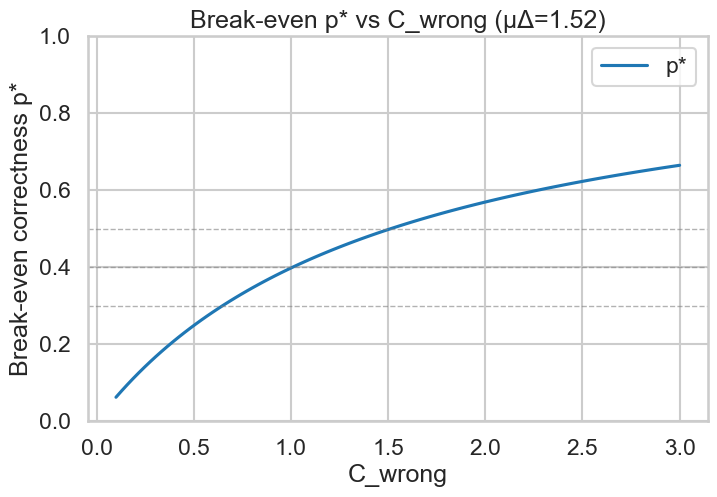

In [16]:

C_grid = np.linspace(0.1, 3.0, 100)
p_star = break_even_p(C_grid, mu_delta)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(C_grid, p_star, label="p*")
for h in [0.3, 0.4, 0.5]:
    ax.axhline(h, color="grey", ls="--", lw=1, alpha=0.6)
ax.set_xlabel("C_wrong")
ax.set_ylabel("Break-even correctness p*")
ax.set_title(f"Break-even p* vs C_wrong (μΔ={mu_delta:.2f})")
ax.set_ylim(0, 1)
ax.legend()
plt.show()



## 2) Expected returns table (solve vs fail)
Rows = `(C_wrong, k_s, k_u)`; columns = `F_start × p` for solve and worst-case fail over `q`.


In [17]:

records = []
for C_wrong in C_wrongs:
    for k_s in k_s_values:
        for k_u in k_u_values:
            row = {"C_wrong": C_wrong, "k_s": k_s, "k_u": k_u}
            for F in F_starts:
                for p in p_values:
                    r_solve = expected_return_solve(F, mu_delta, p, C_wrong, k_s)
                    r_fail_worst = min(expected_return_fail(F, q, mu_delta, p, C_wrong, k_u) for q in q_values)
                    row[(F, p, "solve")] = r_solve
                    row[(F, p, "fail_worst_q")] = r_fail_worst
            records.append(row)

df_returns = pd.DataFrame.from_records(records)
df_returns.set_index(["C_wrong", "k_s", "k_u"], inplace=True)
flat_cols = []
for F, p, kind in df_returns.columns:
    flat_cols.append(f"F{F}_p{p}_{kind}")
df_returns.columns = flat_cols

solve_cols = [c for c in df_returns.columns if c.endswith("solve")]
fail_cols = [c for c in df_returns.columns if c.endswith("fail_worst_q")]
solve_min_good = 0.5 * np.mean(F_starts)

def color_fn(val, kind):
    if kind == "solve":
        if val <= 0:
            return "background-color: #f8d7da"
        if val >= solve_min_good:
            return "background-color: #d4edda"
    else:
        if val >= 0:
            return "background-color: #f8d7da"
        if val <= -0.5 * np.mean(F_starts):
            return "background-color: #d4edda"
    return ""

styles = pd.DataFrame("", index=df_returns.index, columns=df_returns.columns)
for col in solve_cols:
    styles[col] = df_returns[col].apply(lambda v: color_fn(v, "solve"))
for col in fail_cols:
    styles[col] = df_returns[col].apply(lambda v: color_fn(v, "fail"))

styled = df_returns.style.set_caption("Expected returns (solve vs worst-case fail)")
styled = styled.format(precision=1)
styled = styled.set_table_styles([{ "selector": "caption", "props": "caption-side: top; font-weight: bold;"}])
styled = styled.apply(lambda _: styles, axis=None)
styled



## 3) Solve–Fail separation heatmap
`ΔR = R_solve - R_fail` averaged over all `F_start × p × q` combos.


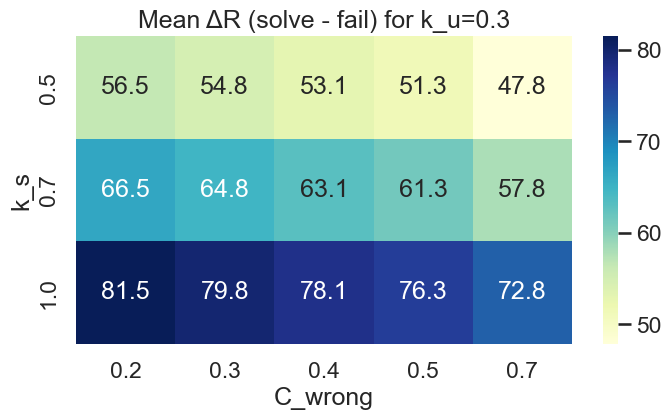

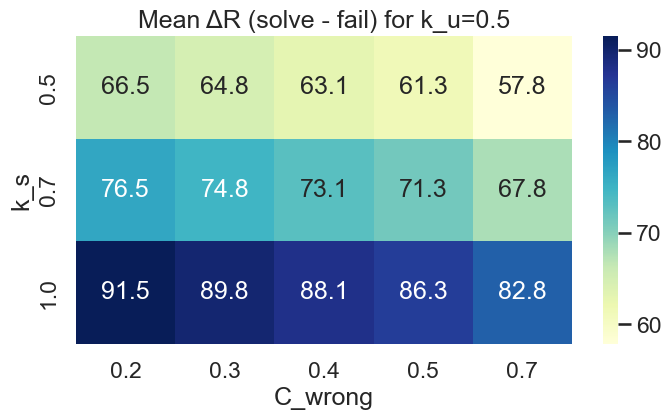

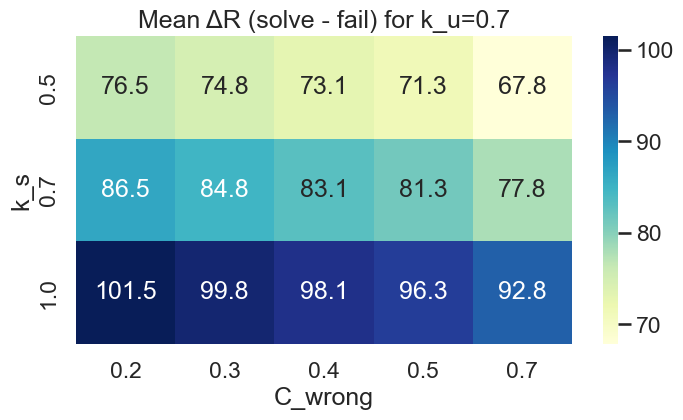

In [18]:

for k_u in k_u_values:
    rows = []
    for k_s in k_s_values:
        row = []
        for C_wrong in C_wrongs:
            deltas = []
            for F in F_starts:
                for p in p_values:
                    r_s = expected_return_solve(F, mu_delta, p, C_wrong, k_s)
                    for q in q_values:
                        r_f = expected_return_fail(F, q, mu_delta, p, C_wrong, k_u)
                        deltas.append(r_s - r_f)
            row.append(np.mean(deltas))
        rows.append(row)
    data = np.array(rows)
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(
        data,
        annot=True,
        fmt=".1f",
        xticklabels=C_wrongs,
        yticklabels=k_s_values,
        cmap="YlGnBu",
        ax=ax,
    )
    ax.set_xlabel("C_wrong")
    ax.set_ylabel("k_s")
    ax.set_title(f"Mean ΔR (solve - fail) for k_u={k_u}")
    plt.show()



## Quick-read summary
Select the triple that maximizes mean ΔR while keeping solve>0 and fail<0 across all configs.


In [19]:

# Compute scores
def score_triples():
    scores = []
    for C_wrong in C_wrongs:
        for k_s in k_s_values:
            for k_u in k_u_values:
                deltas = []
                fail_all_negative = True
                solve_all_positive = True
                for F in F_starts:
                    for p in p_values:
                        r_s = expected_return_solve(F, mu_delta, p, C_wrong, k_s)
                        if r_s <= 0:
                            solve_all_positive = False
                        for q in q_values:
                            r_f = expected_return_fail(F, q, mu_delta, p, C_wrong, k_u)
                            if r_f >= 0:
                                fail_all_negative = False
                            deltas.append(r_s - r_f)
                scores.append({
                    "C_wrong": C_wrong,
                    "k_s": k_s,
                    "k_u": k_u,
                    "mean_deltaR": float(np.mean(deltas)),
                    "solve_all_positive": solve_all_positive,
                    "fail_all_negative": fail_all_negative,
                })
    return scores

scores = score_triples()
best = sorted(scores, key=lambda x: x["mean_deltaR"], reverse=True)[0]
best_ok = [s for s in scores if s["solve_all_positive"] and s["fail_all_negative"]]
print("Top ΔR triple (no feasibility filter):", best)
if best_ok:
    best_feasible = sorted(best_ok, key=lambda x: x["mean_deltaR"], reverse=True)[0]
    print("Best triple with solve>0 & fail<0 everywhere:", best_feasible)
else:
    print("No triple satisfies solve>0 and fail<0 across all configs; inspect table.")


Top ΔR triple (no feasibility filter): {'C_wrong': 0.2, 'k_s': 1.0, 'k_u': 0.7, 'mean_deltaR': 101.52759221662545, 'solve_all_positive': True, 'fail_all_negative': False}
Best triple with solve>0 & fail<0 everywhere: {'C_wrong': 0.5, 'k_s': 1.0, 'k_u': 0.7, 'mean_deltaR': 96.31898054156359, 'solve_all_positive': True, 'fail_all_negative': True}
